In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

from dataclasses import dataclass
%load_ext autoreload
%autoreload 2

In [2]:
from occupancy import *


# Most basic negative sum
In general nse wants to detect a point where different subtractions all reach 0 at the same time.
The basic equation is $F_0 - N \Delta F$. Ideally $\frac{F_0}{\Delta F} = N$ for all $q$. 


In [70]:
@dataclass
class Conf:
    size: int
    maxN : int
    umin: float
    umax: float
    trueN: float
    fit_largest: int

conf = Conf(
    size = 500,
    maxN = 20,
    umin= 7.5,
    umax = 8.5,
    trueN = 7,
    fit_largest = 3,
)


In [71]:
def get_negsum(f0, delta, conf):
    allN = np.arange(conf.maxN, dtype=int)
    f1s = f0[None]-delta[None]*allN[:,None]
    negsum = np.array([-np.sum(f1[f1<0]) for f1 in f1s])
    return allN, negsum


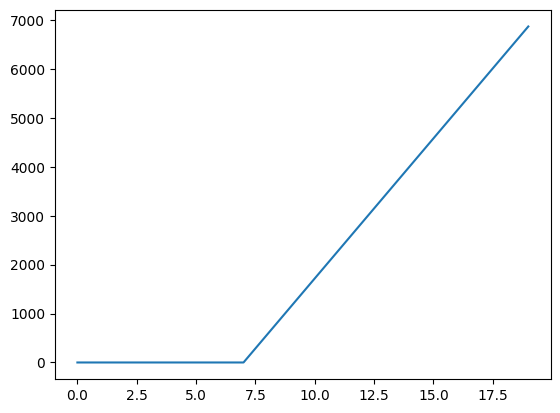

In [72]:

f0 = np.random.uniform(conf.umin,conf.umax,conf.size)
delta = f0/conf.trueN
allN, negsum = get_negsum(f0, delta, conf)
plt.plot(allN,negsum)

8.021902963609055


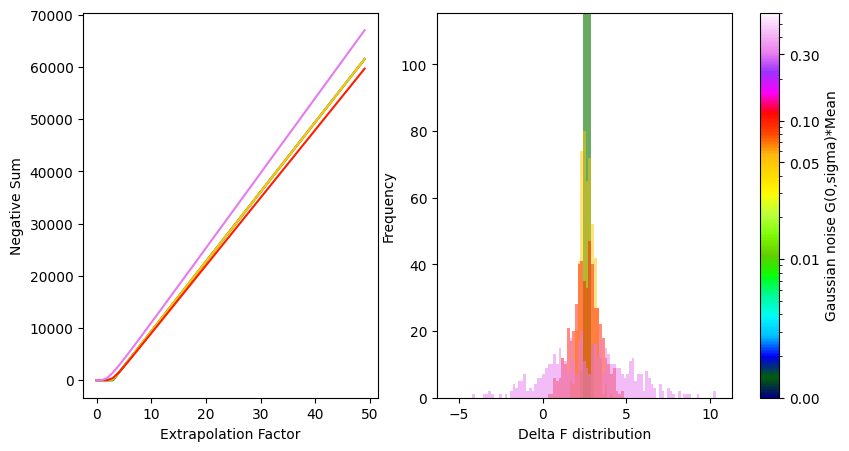

In [92]:
conf = Conf(
    size = 500,
    maxN = 50,
    umin= 7.5,
    umax = 8.5,
    trueN = 3,
    fit_largest = 3,
)
f0 = np.random.uniform(conf.umin,conf.umax,conf.size)
sigmas = [1e-3,0.01, 0.05, 0.1, 0.3]
# sigmas = [1e-9 ,0.3]

cmap = cm.viridis
cmap = cm.gist_ncar
norm = mcolors.LogNorm(vmin=min(sigmas), vmax=max(sigmas)*2)
sm = cm.ScalarMappable(cmap=cmap, norm=norm)

# Plot with colormap
fig, axs = plt.subplots(1,2, figsize=(9,5))
bins = np.linspace(-5.5,10.5,100)
ff = 0
print(np.mean(f0))
for ii, sigma in enumerate(sigmas): 
    color = cmap(norm(sigma))
    noise = np.mean(f0)*np.random.normal(0,sigma, size=conf.size)
    clean_delta = f0/conf.trueN
    delta = clean_delta + noise
    allN, negsum = get_negsum(f0, delta, conf)

    ax = axs[0]
    ax.plot(allN,negsum, color=color, )
    ax.set_ylabel("Negative Sum")
    ax.set_xlabel("Extrapolation Factor")
    ax = axs[1]
    # if (ii+1)%2:
    freq,_,_ =  ax.hist(delta, color=color, alpha=0.5, bins=bins)
    ff = max(np.max(freq),ff)
    ax.set_ylabel("Frequency")
    ax.set_xlabel("Delta F distribution")
ax.set_ylim(0,np.max(ff)/2)
cbar = fig.colorbar(sm, ax=axs, orientation="vertical", fraction=0.03, pad=0.04)
cbar.set_label("Gaussian noise G(0,sigma)*Mean")
cbar.set_ticks(sigmas)
cbar.set_ticklabels([f"{s:.2f}" for s in sigmas])
# axs[0].set_xlim(40,50)
# axs[0].set_ylim(50_000,70_000)
# cbar = plt.colorbar(sm)

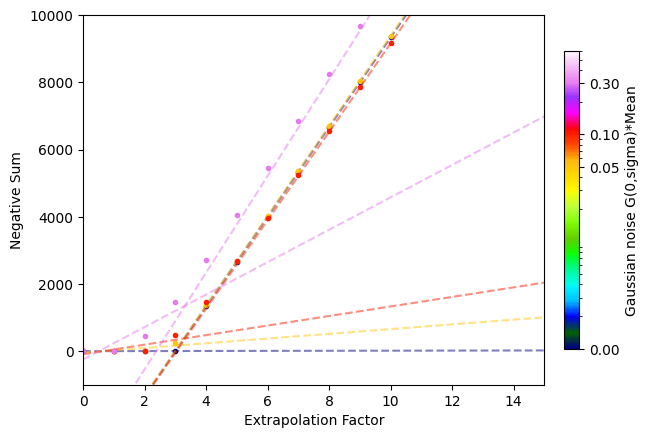

In [89]:
sigmas = [1e-3, 0.05, 0.1, 0.3]
fig, ax = plt.subplots(1,1)
bins = np.linspace(-2,2,100)
for ii, sigma in enumerate(sigmas): 
    color = cmap(norm(sigma))
    noise = np.mean(f0)*np.random.normal(0,sigma, size=conf.size)
    delta = f0/conf.trueN + noise
    allN, negsum = get_negsum(f0, delta, conf)

    alpha_line, fit_lowest, fit_biggest = get_fits(-negsum, allN, conf.fit_largest)
    ax.plot(allN,negsum, ".", color=color, )
    ax.plot(alpha_line,fit_lowest, "--", color=color, alpha=0.5)
    ax.plot(alpha_line,fit_biggest, "--",  color=color, alpha=0.5)
    ax.set_xlim(0,15)
    ax.set_ylim(-1000,10_000)
ax.set_ylabel("Negative Sum")
ax.set_xlabel("Extrapolation Factor")
cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.03, pad=0.04)
cbar.set_label("Gaussian noise G(0,sigma)*Mean")
cbar.set_ticks(sigmas)
cbar.set_ticklabels([f"{s:.2f}" for s in sigmas])
